## firstly you must convert models by your system
dockerfile docker/tensorrt/Dockerfile

convertors:
* yolov5 (inference/convertors/yolo2tensorrt/bin/yolov5_tensorrt.sh)
* options (inference/convertors/options2tensorrt/convert_numberplate_options_to_onnx.py)
* ocrs (inference/convertors/ocr2tensorrt/convert_ocr_to_onnx.py)

In [1]:
import os
import sys

In [2]:
current_dir = os.getcwd()
nomeroff_net_dir = os.path.join(current_dir, "../../../")
sys.path.append(nomeroff_net_dir)

In [3]:
import matplotlib.pyplot as plt
from glob import glob
import pycuda.autoinit

from nomeroff_net.tools import unzip
from nomeroff_net.pipelines.number_plate_detection_and_reading_trt import NumberPlateDetectionAndReadingTrt

In [4]:
number_plate_detection_and_reading_trt = NumberPlateDetectionAndReadingTrt(
    task="number_plate_detection_and_reading_trt", 
    image_loader="opencv",
    
    # numberplate detector trt paths
    path_to_model=os.path.join(nomeroff_net_dir,
                               "./data/model_repository/yolov5s/1/model.engine"),
    # numberplate classification trt paths
    path_to_classification_model=os.path.join(nomeroff_net_dir,
                                              "./data/model_repository/numberplate_options/1/model.trt"),
    options = {
        "class_region": [
                "military",
                "eu_ua_2015",
                "eu_ua_2004",
                "eu_ua_1995",
                "eu",
                "xx_transit",
                "ru",
                "kz",
                "eu-ua-fake-dpr",
                "eu-ua-fake-lpr",
                "ge",
                "by",
                "su",
                "kg",
                "am"
            ],
            "count_lines": [
                1,
                2,
                3
            ],
    },
    
    # numberplate text recognition trt paths
    presets={
        "eu_ua_2004_2015": {
            "for_regions": ["eu_ua_2015", "eu_ua_2004"],
            "model_path": os.path.join(nomeroff_net_dir, 
                                       "./data/model_repository/ocr-eu_ua_2004_2015/1/model.trt")
        },
        "eu_ua_1995": {
            "for_regions": ["eu_ua_1995"],
            "model_path": os.path.join(nomeroff_net_dir,
                                       "./data/model_repository/ocr-eu_ua_1995/1/model.trt")
        },
        "eu": {
            "for_regions": ["eu"],
            "model_path": os.path.join(nomeroff_net_dir,
                                       "./data/model_repository/ocr-eu/1/model.trt")
        },
        "ru": {
            "for_regions": ["ru", "eu-ua-ordlo-lpr", "eu-ua-ordlo-dpr"],
            "model_path": os.path.join(nomeroff_net_dir,
                                       "./data/model_repository/ocr-ru/1/model.trt")
        },
        "kz": {
            "for_regions": ["kz"],
            "model_path": os.path.join(nomeroff_net_dir,
                                       "./data/model_repository/ocr-kz/1/model.trt")
        },
        "ge": {
            "for_regions": ["ge"],
            "model_path": os.path.join(nomeroff_net_dir,
                                       "./data/model_repository/ocr-ge/1/model.trt")
        },
        "su": {
            "for_regions": ["su"],
            "model_path": os.path.join(nomeroff_net_dir,
                                       "./data/model_repository/ocr-su/1/model.trt")
        }
    },
    default_label = "eu",
)

YOLOv5 🚀 v6.1-240-g6dd6aea Python-3.8.12 torch-1.11.0a0+b6df043 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11020MiB)

Loading /var/www/nomeroff-net/examples/ju/inference/../../../data/model_repository/yolov5s/1/model.engine for TensorRT inference...


[05/31/2022-13:21:35] [TRT] [I] [MemUsageChange] Init CUDA: CPU +313, GPU +0, now: CPU 1705, GPU 6826 (MiB)
[05/31/2022-13:21:35] [TRT] [I] Loaded engine size: 43 MiB


Adding AutoShape... 


[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] Init cuBLAS/cuBLASLt: CPU +509, GPU +222, now: CPU 2267, GPU 7094 (MiB)
[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] Init cuDNN: CPU +115, GPU +52, now: CPU 2382, GPU 7146 (MiB)
[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +42, now: CPU 0, GPU 42 (MiB)
[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] Init cuBLAS/cuBLASLt: CPU +0, GPU +10, now: CPU 2338, GPU 7138 (MiB)
[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] Init cuDNN: CPU +0, GPU +8, now: CPU 2338, GPU 7146 (MiB)
[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +69, now: CPU 0, GPU 111 (MiB)
[05/31/2022-13:21:36] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value

[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] Init cuBLAS/cuBLASLt: CPU +0, GPU +8, now: CPU 2369, GPU 7576 (MiB)
[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] Init cuDNN: CPU +0, GPU +8, now: CPU 2369, GPU 7584 (MiB)
[05/31/2022-13:21:36] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +3, now: CPU 0, GPU 330 (MiB)


In [5]:
result = number_plate_detection_and_reading_trt(glob(os.path.join(nomeroff_net_dir,
                                                                  './data/examples/oneline_images/*')))

[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] Init cuBLAS/cuBLASLt: CPU +1, GPU +10, now: CPU 2887, GPU 7893 (MiB)
[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] Init cuDNN: CPU +0, GPU +10, now: CPU 2887, GPU 7903 (MiB)
[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +12, now: CPU 0, GPU 342 (MiB)
[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] Init cuBLAS/cuBLASLt: CPU +0, GPU +10, now: CPU 2888, GPU 7895 (MiB)
[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] Init cuDNN: CPU +1, GPU +8, now: CPU 2889, GPU 7903 (MiB)
[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +12, now: CPU 0, GPU 342 (MiB)
[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] Init cuBLAS/cuBLASLt: CPU +0, GPU +10, now: CPU 2891, GPU 7895 (MiB)
[05/31/2022-13:21:37] [TRT] [I] [MemUsageChange] Init cuDNN: CPU +0, GPU +8, now: CPU 2891, GPU 7903 (MiB)
[05/31/2022-13:21:37] 

In [6]:
(images, images_bboxs, 
 images_points, images_zones, region_ids, 
 region_names, count_lines, 
 confidences, texts) = unzip(result)

['В8233ХА']


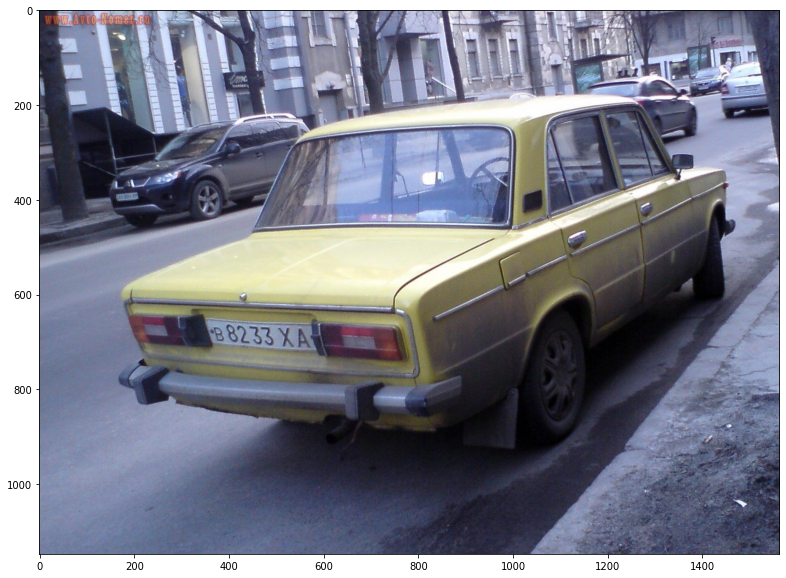

['OO964GG']


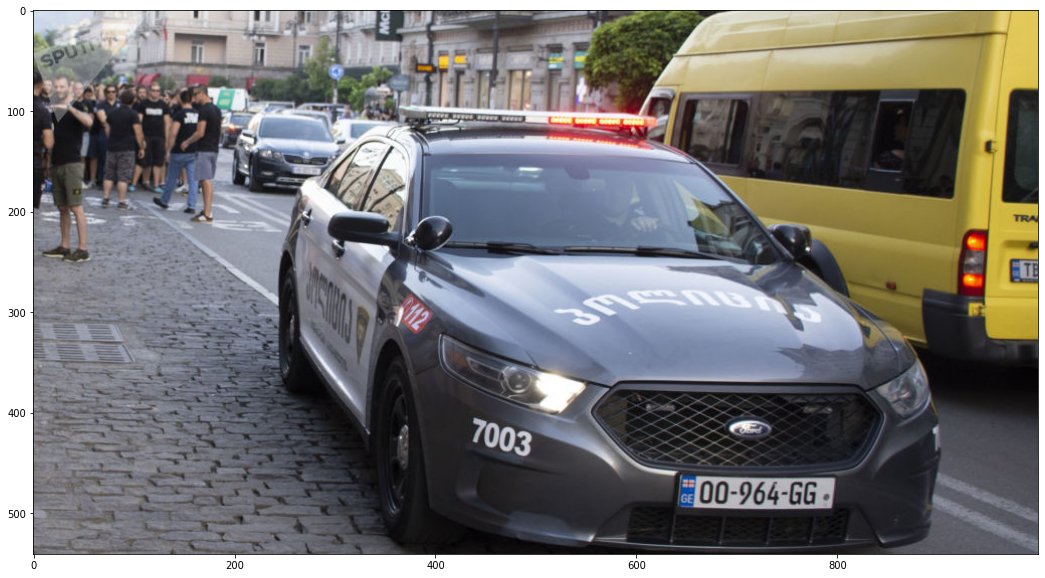

['RP70012', 'JJF509']


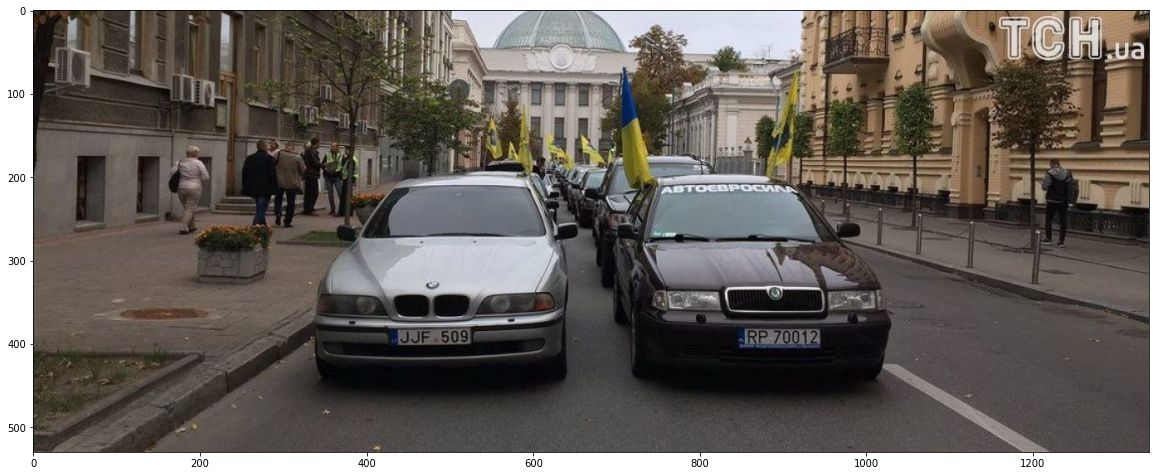

['498VDZ08']


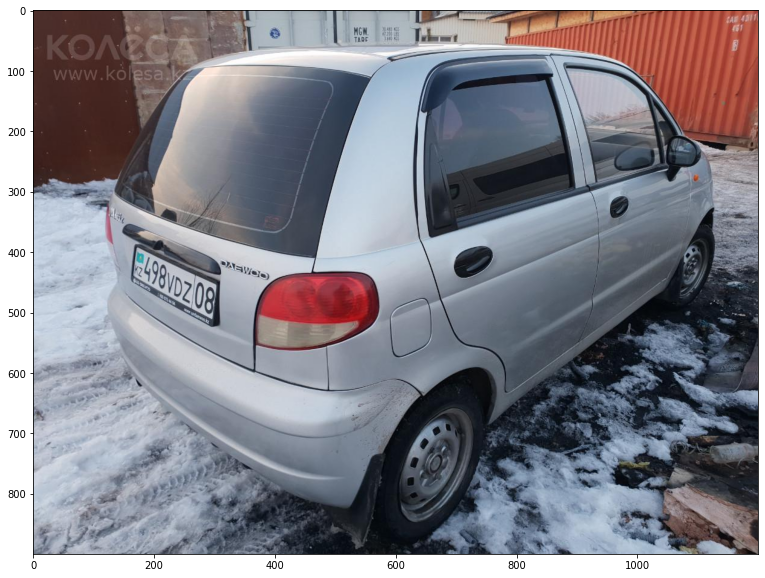

['AC4921CB']


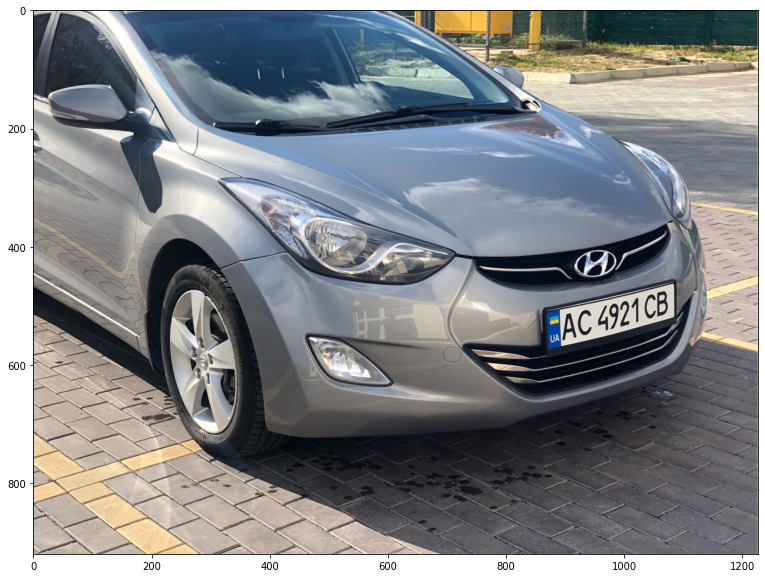

['AA8809T']


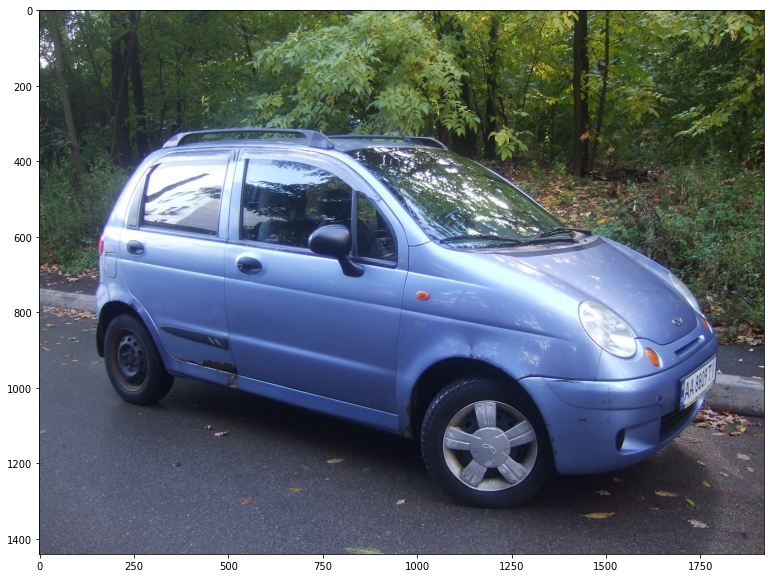

['M556BX159']


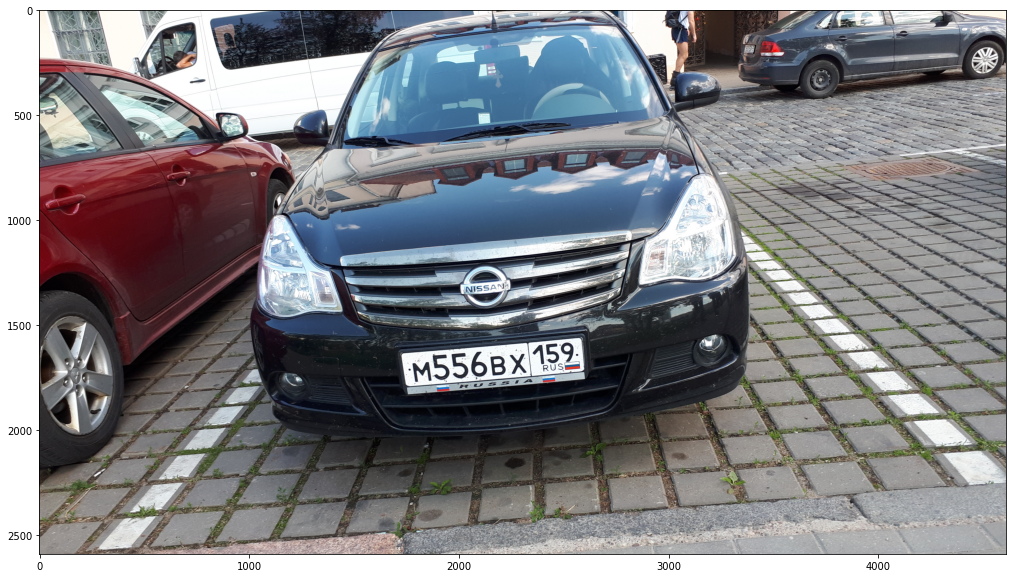

In [7]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (20,10)

for img, np in zip(images, texts):
    print(np)
    plt.imshow(img)
    plt.show()